# Problem - Linear Regression with Gradient Descent

## Interview question

Implement linear regression from scratch using NumPy. Given `X: [N, D]` and `y: [N]`, learn `w: [D]` and scalar `b` by minimizing mean squared error with gradient descent.

## What is being asked

You need to implement the prediction equation, MSE loss, gradients with respect to weights and bias, and the training loop. The interviewer wants to see that you understand basic supervised learning and vectorized gradient computation.

## Clarifying questions

- Should I include an explicit bias term or absorb it into `X`?
- Should I standardize features?
- Should the solution use closed-form least squares or gradient descent?
- What stopping criterion should I use?

## Solution

### Iterative Approach (Gradient Descent)

[[ 0.15772622]
 [ 0.00261948]
 [ 0.06198457]
 [-0.04795916]
 [ 0.1039861 ]
 [-0.10159943]
 [ 0.08440379]
 [ 0.1672848 ]
 [-0.07020583]
 [ 0.0417979 ]]
[[-0.76058222]]


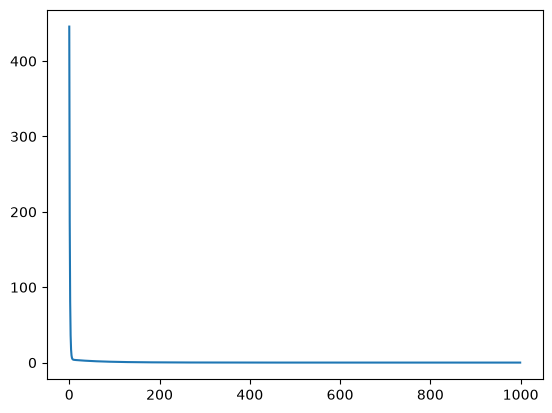

In [37]:
import numpy as np
import matplotlib.pyplot as plt

"""
Problem --> X (NxD) and Y (Nx1) learn W (Dx1) and b (1) such that X@W + b ~= Y

Y' = X@W + b
E = Y' - Y
L = mean(E^2) = 1/N * sum(Ei^2)

diff_L / diff_Wj = 1/N * sum(2Ei * diff_Ei/diff_Wj) = 1/N * sum(2Ei * (Xij))
diff_L / diff_W = 2/N * X.T@E

diff_L / diff_b = 1/N * sum(2Ei * diff_Ei/diff_b) =  1/N * sum(2Ei)
diff_L / diff_b = 2/N * sum(E)

"""

def linear_regression_fit_gd(X: np.ndarray, Y: np.ndarray, lr: float = 0.1, num_steps: int = 1000) -> np.ndarray:
    N = X.shape[0]
    D = X.shape[1]

    W = np.random.rand(D, 1)
    b = np.random.rand(1, 1)

    losses = []

    for _ in range(num_steps):
        Y_p = X@W + b
        E = Y_p - Y
        L = (E**2).mean()
        losses.append(L)

        g_w = 1/N * X.T@E
        g_b = 1/N * E.sum()

        W -= lr*g_w
        b -= lr*g_b

    return W, b, losses


if __name__ == "__main__":
    n = 100
    d = 10
    X = np.random.rand(n, d)

    gt_W = np.random.randint(0, 9, (d,1))
    gt_b = np.random.randint(0,9, 1)

    Y = X@gt_W+gt_b+np.random.rand(n, 1)

    p_W, p_b, losses = linear_regression_fit_gd(X, Y)

    print(gt_W-p_W)
    print(gt_b-p_b)

    plt.plot(np.arange(len(losses)), losses)


### Closed Form Formula (Normal Equation)

In [43]:
"""
(X.T @ X)^-1 @ X.T @ Y
"""


def linear_fit_single_step(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    return np.linalg.inv(X.T @ X) @ X.T @ Y

if __name__ == "__main__":
    n = 100
    d = 11
    X = np.random.rand(n, d)

    gt_W = np.random.randint(0, 9, (d,1))
    gt_b = np.random.randint(0,9, 1)

    Y = X@gt_W+gt_b+np.random.rand(n, 1)

    p_W = linear_fit_single_step(X, Y)
    p_b = p_W[-1]
    p_W = p_W[: -1]

    print(gt_W[:-1]-p_W)
    print(gt_W[-1]-p_b)
    
    

[[-0.82335307]
 [-1.78468395]
 [-1.74567684]
 [-2.13540994]
 [-1.82871616]
 [-2.33760095]
 [-2.06025752]
 [-1.62101353]
 [-0.40161698]
 [-1.83735901]]
[-0.07347543]


## Notes

* Gradient Descent Vs Stochastic Gradient Descent
    * GD calculates the gradient using entire dataset
    * SGD does it on a batch
* Negative sign in gradient descent update:
    * Gradient --> slop of loss function 
    * Positive gradient (slop is positive), moving left (subtract) would reduce the loss, hense (w-=(|g|))
    * Negative gradient (slop is negative), moving right (adding) would reduce loss loss, hense (w-=(-|g|) --> w+=|g|)
